# **Employee Turnover Prediction**


## Understand the business scenario

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. \

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company. 

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

---

## Business Problem
Employee turnover is expensive and affects organizational performance. HR wants to understand:

- Why employees leave
- Which employees are most likely to leave
- What factors contribute most to attrition

This project uses:
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Machine learning models
- Feature importance analysis

to generate actionable insights.

---

## Project Overview
This project analyzes employee attrition data to identify the major factors responsible for employee turnover.

The project uses:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Models
- XGBoost Classification

to generate business insights and HR recommendations.



# Salifort Motors Employee Turnover Analysis

## Project Objective
The purpose of this project is to analyze employee turnover data and build machine learning models that predict whether an employee will leave the company.

The analysis will help Salifort Motors understand the main factors affecting employee retention and provide recommendations to reduce turnover.

# Step 1: Import Required Libraries

In this step, we import the Python libraries needed for:
- Data analysis
- Data visualization
- Machine learning
- Model evaluation

In [4]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load the Dataset

The dataset contains employee information such as:
- Satisfaction level
- Monthly working hours
- Salary
- Department
- Number of projects
- Employee turnover status

The target variable is:
- `left`
    - 1 = Employee left the company
    - 0 = Employee stayed

In [5]:
# Load dataset
hr = pd.read_csv('/Users/rks1444/Desktop/MAC/Project/employee_turnover_prediction/HR_comma_sep.csv')
# Display first 5 rows
hr.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


# Step 3: Explore the Dataset

Before building models, it is important to understand:
- Number of rows and columns
- Data types
- Statistical summary
- Missing values

In [6]:
# Dataset shape
hr.shape

(14999, 10)

In [7]:
# Column names
hr.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='str')

In [8]:
# Dataset information
hr.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [9]:
# Statistical summary
hr.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


# Step 4: Data Cleaning

In this step:
- Check for missing values
- Check for duplicate records
- Remove duplicates if necessary

In [10]:
# Missing values
hr.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [11]:
# Duplicate rows
hr.duplicated().sum()

np.int64(3008)

In [12]:
# Remove duplicates
hr = hr.drop_duplicates()

# Employee Turnover Distribution

This visualization shows the number of employees who stayed and left the company.

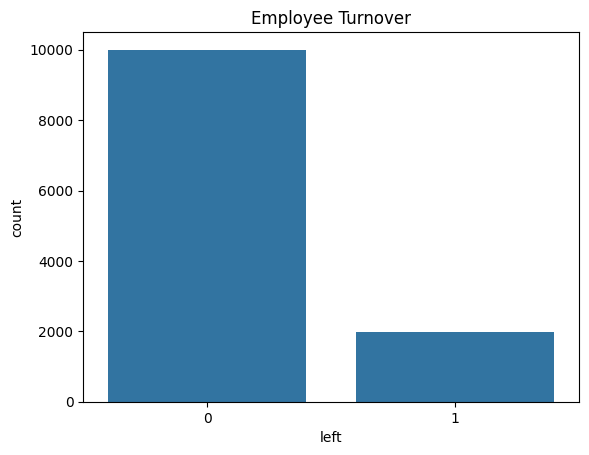

In [13]:
sns.countplot(x='left', data=hr)
plt.title('Employee Turnover')
plt.show()

### Observation
Most employees stayed in the company, but a significant number left the organization.

# Satisfaction Level vs Employee Turnover

This analysis helps determine whether employee satisfaction affects turnover.

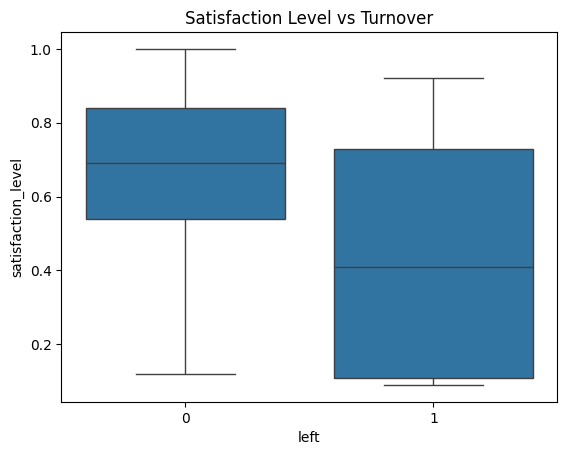

In [14]:
sns.boxplot(x='left', y='satisfaction_level', data=hr)
plt.title('Satisfaction Level vs Turnover')
plt.show()

### Observation
Employees who left the company had lower satisfaction levels compared to employees who stayed.

# Monthly Working Hours vs Turnover

This visualization shows whether long working hours contribute to employee turnover.

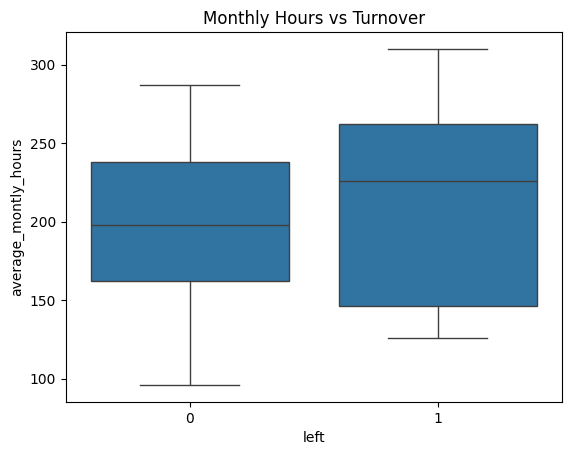

In [15]:
sns.boxplot(x='left', y='average_montly_hours', data=hr)
plt.title('Monthly Hours vs Turnover')
plt.show()

### Observation
Employees who worked excessive monthly hours were more likely to leave the company.

# Salary vs Employee Turnover

This analysis examines the relationship between salary level and employee turnover.

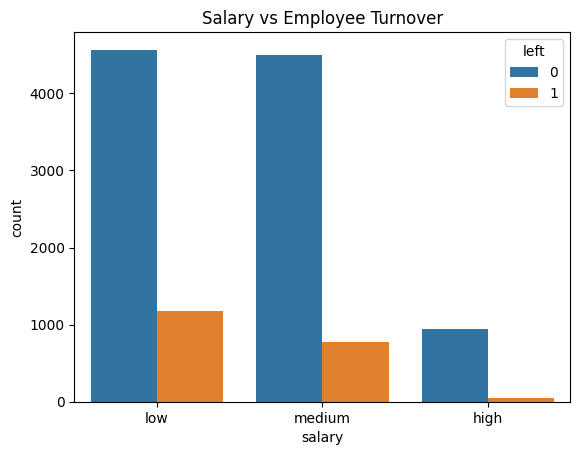

In [16]:
sns.countplot(x='salary', hue='left', data=hr)
plt.title('Salary vs Employee Turnover')
plt.show()

### Observation
Employees with low salaries had higher turnover compared to medium and high salary employees.

# Step 6: Convert Categorical Variables

Machine learning models require numerical input.

The categorical columns:
- department
- salary

will be converted into numerical values using one-hot encoding.

In [17]:
# Convert categorical variables
hr_encoded = pd.get_dummies(hr, drop_first=True)

hr_encoded.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


# Step 7: Define Features and Target Variable

Features (`X`) are the independent variables.

Target (`y`) is the variable we want to predict:
- `left`

In [18]:
# Features
X = hr_encoded.drop('left', axis=1)

# Target
y = hr_encoded['left']

# Step 8: Split the Dataset

The dataset is divided into:
- Training data (80%)
- Testing data (20%)

Training data is used to train the model.

Testing data is used to evaluate model performance.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Step 9: Logistic Regression Model

Logistic regression is a statistical model used for binary classification problems.

In this project, it predicts:
- Employee stays
- Employee leaves

In [20]:
# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

In [21]:
# Accuracy score
accuracy_score(y_test, y_pred_log)

0.8328470195914964

In [22]:
# Classification report
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.85      0.97      0.91      1998
           1       0.50      0.17      0.26       401

    accuracy                           0.83      2399
   macro avg       0.68      0.57      0.58      2399
weighted avg       0.79      0.83      0.80      2399



In [23]:
# Confusion matrix
confusion_matrix(y_test, y_pred_log)

array([[1929,   69],
       [ 332,   69]])

### Observation
The logistic regression model provides acceptable performance, but it may not fully capture complex employee behavior patterns.

# Step 10: Decision Tree Model

Decision trees split the data into branches based on feature importance.

This model is useful for identifying non-linear relationships.

In [24]:
# Create model
tree_model = DecisionTreeClassifier(random_state=42)

# Train model
tree_model.fit(X_train, y_train)

# Predictions
y_pred_tree = tree_model.predict(X_test)

In [25]:
accuracy_score(y_test, y_pred_tree)

0.9633180491871614

In [26]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1998
           1       0.88      0.91      0.89       401

    accuracy                           0.96      2399
   macro avg       0.93      0.94      0.94      2399
weighted avg       0.96      0.96      0.96      2399



### Observation
The decision tree model performed better than logistic regression because it captured more complex patterns in employee turnover.

# Step 11: Random Forest Model

Random forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [27]:
# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

In [28]:
accuracy_score(y_test, y_pred_rf)

0.9783243017924135

In [29]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1998
           1       0.98      0.89      0.93       401

    accuracy                           0.98      2399
   macro avg       0.98      0.94      0.96      2399
weighted avg       0.98      0.98      0.98      2399



### Observation
The random forest model achieved the best performance among all models.

# Step 12: Feature Importance Analysis

Feature importance helps identify which variables have the strongest impact on employee turnover.

In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
0,satisfaction_level,0.341297
4,time_spend_company,0.170353
2,number_project,0.167576
3,average_montly_hours,0.160608
1,last_evaluation,0.123300
5,Work_accident,0.007452
16,salary_low,0.005848
13,Department_sales,0.003560
15,Department_technical,0.003445
17,salary_medium,0.003346


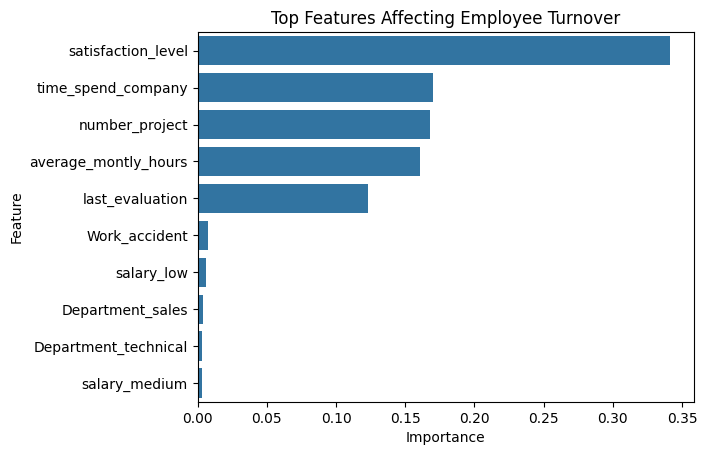

In [31]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title('Top Features Affecting Employee Turnover')
plt.show()

# XGBoost Model

## Why XGBoost?
XGBoost is an advanced boosting algorithm widely used for structured datasets because of:
- High accuracy
- Fast performance
- Better handling of complex patterns
- Reduced overfitting

The model predicts whether an employee is likely to leave the company.


In [32]:
# Import XGBoost
from xgboost import XGBClassifier

# Create model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy Score:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))


Accuracy Score: 0.9795748228428511

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1998
           1       0.97      0.91      0.94       401

    accuracy                           0.98      2399
   macro avg       0.98      0.95      0.96      2399
weighted avg       0.98      0.98      0.98      2399


Confusion Matrix:

[[1987   11]
 [  38  363]]


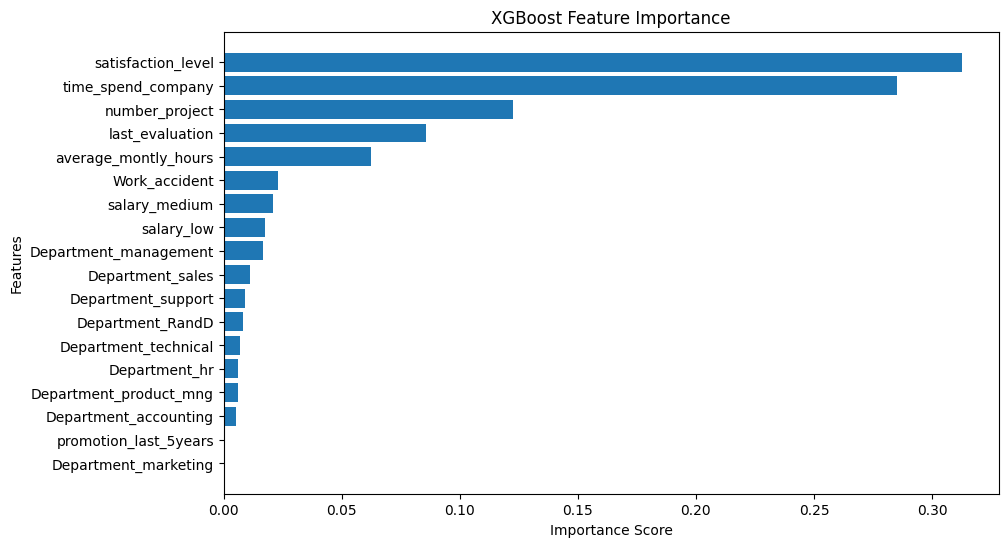

In [33]:
# Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()


# Key Findings

1. Employees with low satisfaction levels were more likely to leave.

2. Employees working excessive hours showed higher turnover.

3. Employees with low salaries had increased chances of leaving.

4. Employees handling too many projects were more likely to quit.

5. Limited promotion opportunities may contribute to turnover.

# Business Recommendations

## Recommendation 1
Improve employee satisfaction through regular feedback programs.

## Recommendation 2
Reduce excessive workloads and balance project assignments.

## Recommendation 3
Review salary structures for low salary employees.

## Recommendation 4
Increase promotion and career development opportunities.

## Recommendation 5
Monitor employees with high workloads and low satisfaction levels.

# Final Conclusion

This project analyzed employee turnover at Salifort Motors using machine learning models.

The following models were developed:
- Logistic Regression
- Decision Tree
- Random Forest

Among these models, Random Forest achieved the best performance.

The analysis showed that:
- Satisfaction level
- Workload
- Number of projects
- Salary

are major factors affecting employee turnover.

These insights can help Salifort Motors improve employee retention and reduce recruitment and training costs.